In [11]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn ipykernel sqlalchemy

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 262.6 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 375.8 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 375.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 232.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.2/36.5 MB 5.0 MB/s eta 0:00:08
    --------------------------------------- 0.6/36.5 MB 6.4 MB/s eta 0:00:06
   - -------------------------------------- 1.8/36.5 MB 11.4 MB/s eta 0:00:04
   --- ------------------------------------ 2.8/36.5 MB 13.7 MB/s eta 0:00:03
   ---- ----------------------------------- 4.0/36.5 MB 15.0 MB/s eta 0:00:03
   ----- ---------------------------------- 5.4/36.5 MB 16.5 MB/s eta 0:00:02


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import sqlite3
import os

# ==========================================
# 1. Load Data: อ่านไฟล์ (แก้ใหม่ให้หาไฟล์รอบตัว)
# ==========================================
print("🚀 Loading datasets...")

# ฟังก์ชันช่วยอ่านไฟล์ (แก้ตรงนี้!)
def load_data(filename):
    # ไม่ต้องมี os.path.join('data', ...) แล้ว เพราะไฟล์อยู่กองเดียวกัน
    return pd.read_csv(filename)

# โหลดทุกไฟล์
try:
    orders = load_data('olist_orders_dataset.csv')
    items = load_data('olist_order_items_dataset.csv')
    products = load_data('olist_products_dataset.csv')
    payments = load_data('olist_order_payments_dataset.csv')
    reviews = load_data('olist_order_reviews_dataset.csv')
    customers = load_data('olist_customers_dataset.csv')
    # geolocation = load_data('olist_geolocation_dataset.csv') 
    sellers = load_data('olist_sellers_dataset.csv')
    category_translation = load_data('product_category_name_translation.csv')
    print("✅ Data Loaded Successfully!")
except FileNotFoundError as e:
    print(f"❌ ยังหาไฟล์ไม่เจอ: {e}")

# ==========================================
# 2. Setup SQL Database: สร้าง DB จำลอง
# ==========================================
# (ส่วนนี้เหมือนเดิม แต่ใส่ if ตรวจสอบว่าโหลดข้อมูลผ่านไหมก่อนรัน)
if 'orders' in locals(): 
    print("⚙️ Creating SQL Database in Memory...")
    conn = sqlite3.connect(':memory:')

    orders.to_sql('orders', conn, index=False, if_exists='replace')
    items.to_sql('items', conn, index=False, if_exists='replace')
    products.to_sql('products', conn, index=False, if_exists='replace')
    payments.to_sql('payments', conn, index=False, if_exists='replace')
    reviews.to_sql('reviews', conn, index=False, if_exists='replace')
    customers.to_sql('customers', conn, index=False, if_exists='replace')
    category_translation.to_sql('translations', conn, index=False, if_exists='replace')

    # ==========================================
    # 3. SQL Query: เชื่อมตาราง
    # ==========================================
    query = """
    SELECT 
        o.order_id,
        o.customer_id,
        o.order_status,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        i.product_id,
        i.price,
        i.freight_value,
        c.customer_unique_id,
        c.customer_city,
        c.customer_state,
        t.product_category_name_english AS category_name,
        p.payment_type,
        p.payment_value,
        r.review_score,
        r.review_comment_message

    FROM orders o
    LEFT JOIN items i ON o.order_id = i.order_id AND i.order_item_id = 1 
    LEFT JOIN products prod ON i.product_id = prod.product_id
    LEFT JOIN translations t ON prod.product_category_name = t.product_category_name
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    LEFT JOIN payments p ON o.order_id = p.order_id AND p.payment_sequential = 1
    LEFT JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    """

    # ==========================================
    # 4. Run Query & Clean Up
    # ==========================================
    print("🔍 Executing Join Query...")
    df_master = pd.read_sql(query, conn)
    conn.close()

    # แปลงวันที่
    df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])
    df_master['order_delivered_customer_date'] = pd.to_datetime(df_master['order_delivered_customer_date'])
    
    # สร้างตัวแปรระยะเวลาส่ง
    df_master['delivery_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days

    print("🎉 DONE! Master DataFrame is ready.")
    print(f"Total Rows: {len(df_master)}")
    
    # แสดงผล
    display(df_master.head()) # ใช้ display() ใน notebook จะสวยกว่า print

🚀 Loading datasets...
✅ Data Loaded Successfully!
⚙️ Creating SQL Database in Memory...
🔍 Executing Join Query...
🎉 DONE! Master DataFrame is ready.
Total Rows: 97007


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,product_id,price,freight_value,customer_unique_id,customer_city,customer_state,category_name,payment_type,payment_value,review_score,review_comment_message,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,87285b34884572647811a353c7ac498a,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,housewares,credit_card,18.12,4.0,"Não testei o produto ainda, mas ele veio corre...",8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,af07308b275d755c9edb36a90c618231,barreiras,BA,perfumery,boleto,141.46,4.0,Muito bom o produto.,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,aa4383b373c6aca5d8797843e5594415,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,auto,credit_card,179.12,5.0,NaN,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,pet_shop,credit_card,72.20,5.0,O produto foi exatamente o que eu esperava e e...,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,stationery,credit_card,28.62,5.0,NaN,2.0


In [6]:
# ==========================================
# 5. Data Validation (เช็คสุขภาพข้อมูล)
# ==========================================
print("📊 Checking Missing Values...")
# ดูว่ามีช่องว่าง (Null) ตรงไหนบ้าง
print(df_master.isnull().sum())

# ==========================================
# 6. RFM Preparation (เตรียมทำ RFM)
# ==========================================
print("\n🛠️ Calculating RFM...")

# กำหนด "วันปัจจุบัน" เพื่อใช้คำนวณ Recency 
# (สมมติว่าเป็น 1 วันหลังจากออเดอร์สุดท้ายในระบบ)
last_date = df_master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Group ข้อมูลตามลูกค้า (Unique ID)
rfm = df_master.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (last_date - x.max()).days, # Recency (ไม่ได้ซื้อมานานกี่วัน)
    'order_id': 'count',      # Frequency (ซื้อไปกี่ครั้ง - นับจากจำนวน Item ที่ Join มา)
    'payment_value': 'sum'    # Monetary (จ่ายไปเท่าไหร่)
}).reset_index()

# เปลี่ยนชื่อคอลัมน์ให้เข้าใจง่าย
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# กรองเฉพาะคนที่มีค่า Monetary > 0 (เผื่อมี error)
rfm = rfm[rfm['Monetary'] > 0]

print("✅ RFM Table Created!")
print(f"Total Customers: {len(rfm)}")
display(rfm.head())

# ==========================================
# 7. (Optional) Save to CSV (เซฟเก็บไว้ใช้ทีหลัง)
# ==========================================
# rfm.to_csv('rfm_result.csv', index=False)
# print("💾 Saved rfm_result.csv")

📊 Checking Missing Values...
order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_delivered_customer_date        8
product_id                           0
price                                0
freight_value                        0
customer_unique_id                   0
customer_city                        0
customer_state                       0
category_name                     1386
payment_type                        79
payment_value                       79
review_score                       646
review_comment_message           57908
delivery_days                        8
dtype: int64

🛠️ Calculating RFM...
✅ RFM Table Created!
Total Customers: 93281


,customer_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [7]:
# ==========================================
# 5. Data Cleaning (จัดการค่าว่างแบบถูกวิธี)
# ==========================================
print(f"Original Row Count: {len(df_master)}")

# 1. จัดการ Review Comment: ถ้าว่าง ให้ใส่ว่า 'No Comment'
df_master['review_comment_message'] = df_master['review_comment_message'].fillna('No Comment')

# 2. จัดการ Category: ถ้าว่าง ให้ใส่ว่า 'Unknown'
df_master['category_name'] = df_master['category_name'].fillna('Unknown')

# 3. จัดการส่วนที่เหลือ: ค่าพวกนี้สำคัญ ถ้าไม่มีคำนวณไม่ได้ และมีจำนวนน้อย -> ลบทิ้งได้
cols_to_drop = ['order_delivered_customer_date', 'payment_value', 'review_score', 'delivery_days']
df_master = df_master.dropna(subset=cols_to_drop)

print(f"Cleaned Row Count: {len(df_master)}")
print("✅ Data is clean now!")

# เช็คอีกรอบให้ชัวร์
print(df_master.isnull().sum())

Original Row Count: 97007
Cleaned Row Count: 96275
✅ Data is clean now!
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    0
product_id                       0
price                            0
freight_value                    0
customer_unique_id               0
customer_city                    0
customer_state                   0
category_name                    0
payment_type                     0
payment_value                    0
review_score                     0
review_comment_message           0
delivery_days                    0
dtype: int64


In [8]:
# ==========================================
# 6. RFM Segmentation (ตัดเกรดลูกค้า)
# ==========================================
# (ต้องรันโค้ดคำนวณ RFM ก่อนหน้านี้ก่อนนะ)

# ใช้ฟังก์ชัน qcut เพื่อแบ่งลูกค้าเป็น 5 เกรด (1-5) ตาม Percentile
# R_Score: ยิ่งน้อยยิ่งดี (เพิ่งซื้อ) -> label สลับด้าน
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# F_Score: ยิ่งมากยิ่งดี (ซื้อบ่อย) -> เนื่องจากข้อมูลซ้ำเยอะ เราจะใช้ rank(method='first') ช่วย
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# M_Score: ยิ่งมากยิ่งดี (จ่ายหนัก)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# รวมคะแนน RFM (เอามาต่อกันเป็น String เช่น "555" คือเทพสุด)
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# คำนวณ RFM Score รวม (แบบตัวเลข)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# สร้างฟังก์ชันแบ่งกลุ่มตามคะแนน (Segment Logic)
def segment_customer(df):
    if df['RFM_Score'] >= 13:
        return 'Champions' # ลูกค้าเกรด A+ (ซื้อบ่อย เพิ่งซื้อ จ่ายหนัก)
    elif df['RFM_Score'] >= 10:
        return 'Loyal Customers' # ลูกค้าประจำ
    elif df['RFM_Score'] >= 7:
        return 'Potential Loyalist' # มีแววจะรุ่ง
    elif df['R_Score'] == 1: 
        return 'Hibernating' # หลับไปแล้ว (นานๆ ซื้อที และหายไปนานแล้ว)
    else:
        return 'At Risk' # กลุ่มเสี่ยงจะเลิกซื้อ

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

# แสดงผลลัพธ์
print("🎯 Segmentation Summary:")
print(rfm['Customer_Segment'].value_counts())
display(rfm.head())

🎯 Segmentation Summary:
Customer_Segment
Potential Loyalist    38338
Loyal Customers       31493
Champions              8061
Hibernating            7865
At Risk                7524
Name: count, dtype: int64


,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9,Potential Loyalist
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6,At Risk
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,3,113,5,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,Potential Loyalist


In [9]:
%pip install seaborn matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 390.8 kB/s eta 0:00:00
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     ------------------------------ -------- 92.2/116.4 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 116.4/116.4 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   --------------------------- ------------ 204.8/294.9 kB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 10.5 MB/s eta 0:00:01
   --- ------------------------------------ 0.6/8.1 MB 6.7 MB/s eta 0:00:02
   ----- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1️⃣ Generating Segmentation Chart...


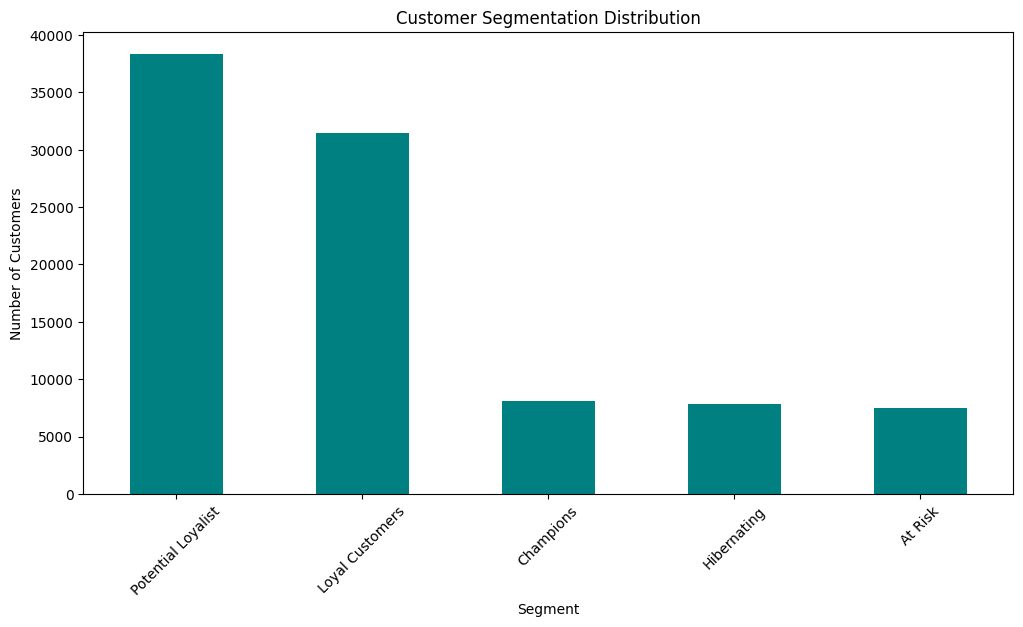

2️⃣ Generating Delivery vs Review Chart...


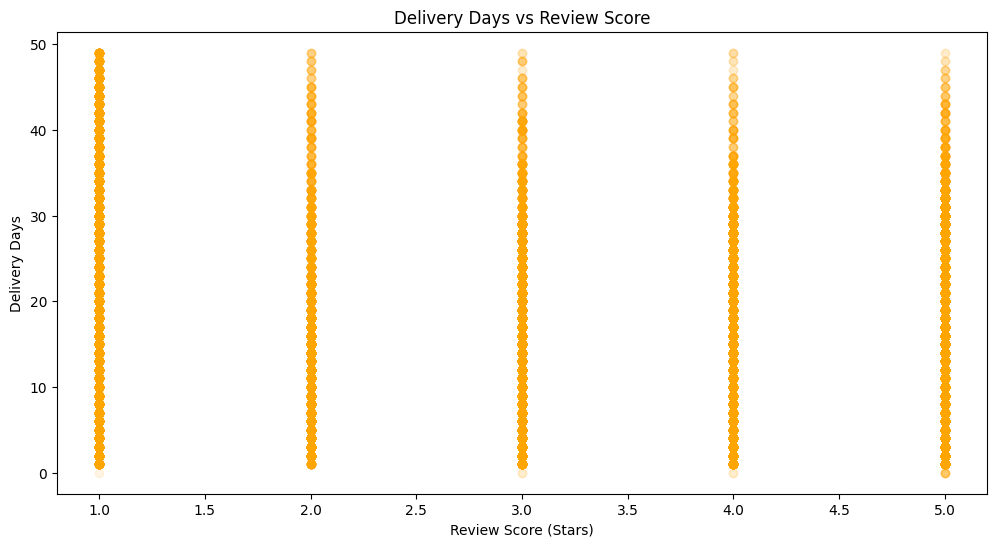

3️⃣ Generating Top Cities Chart...


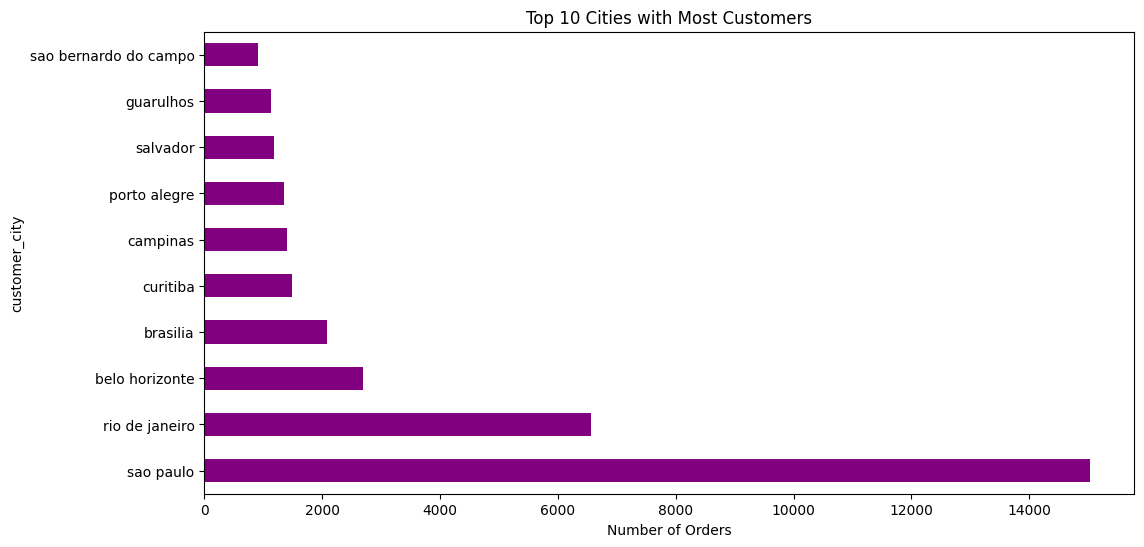

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# ตั้งค่าขนาดกราฟ
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# Graph 1: Customer Segmentation (เรามีลูกค้ากลุ่มไหนเยอะสุด?)
# ==========================================
print("1️⃣ Generating Segmentation Chart...")
# ใช้ pandas plot ธรรมดา
rfm['Customer_Segment'].value_counts().plot(kind='bar', color='teal')
plt.title('Customer Segmentation Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# Graph 2: Delivery Time vs Review Score 
# ==========================================
print("2️⃣ Generating Delivery vs Review Chart...")
# ใช้ Scatter plot แบบพื้นฐาน
plot_data = df_master[df_master['delivery_days'] < 50]
plt.scatter(plot_data['review_score'], plot_data['delivery_days'], alpha=0.1, color='orange')
plt.title('Delivery Days vs Review Score')
plt.xlabel('Review Score (Stars)')
plt.ylabel('Delivery Days')
plt.show()

# ==========================================
# Graph 3: Top 10 Customer Cities
# ==========================================
print("3️⃣ Generating Top Cities Chart...")
top_cities = df_master['customer_city'].value_counts().head(10)
top_cities.plot(kind='barh', color='purple') # barh คือกราฟแท่งแนวนอน
plt.title('Top 10 Cities with Most Customers')
plt.xlabel('Number of Orders')
plt.show()